Liczba próbek w klasach: Counter({np.int64(1): 134, np.int64(0): 23})

Rozpoczynamy 5-krotną walidację krzyżową...

FOLD 1/5
Early Stopping w epoce 93.


C:\Windows\Temp\ipykernel_5324\3510363877.py:189: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(fold_best_model_path))


Najlepsze Accuracy dla FOLD 1: 93.75%

FOLD 2/5
Early Stopping w epoce 163.
Najlepsze Accuracy dla FOLD 2: 100.00%

FOLD 3/5
Early Stopping w epoce 54.
Najlepsze Accuracy dla FOLD 3: 87.10%

FOLD 4/5
Early Stopping w epoce 129.
Najlepsze Accuracy dla FOLD 4: 93.55%

FOLD 5/5
Early Stopping w epoce 93.
Najlepsze Accuracy dla FOLD 5: 93.55%

SZCZEGÓŁOWE WYNIKI ZBIORCZE
Accuracy: 93.63%
Macro F1-score: 0.8726
Cohen's Kappa:  0.7453
Matthews Corrcoef (MCC): 0.7453

Precision per class:
   - Zdrowe (0): 0.7826
   - Cellulit (1): 0.9627

Recall (Sensitivity) per class:
   - Zdrowe (0): 0.7826
   - Cellulit (1): 0.9627

Specificity per class:
   - Zdrowe (0): 0.9627
   - Cellulit (1): 0.7826

----------------------------------------
RAPORT KLASYFIKACJI:
              precision    recall  f1-score   support

  Zdrowe (0)       0.78      0.78      0.78        23
Cellulit (1)       0.96      0.96      0.96       134

    accuracy                           0.94       157
   macro avg       0.87  

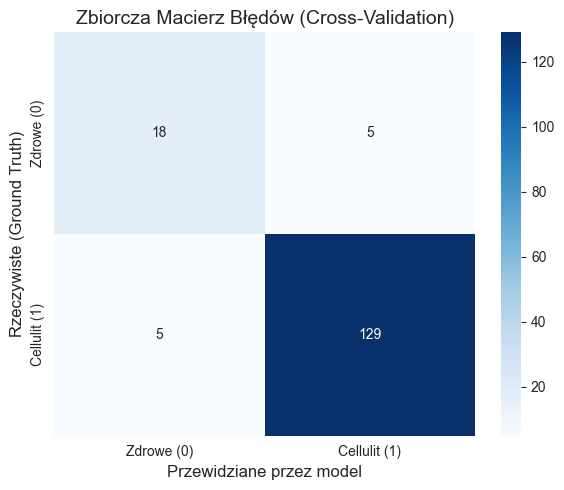

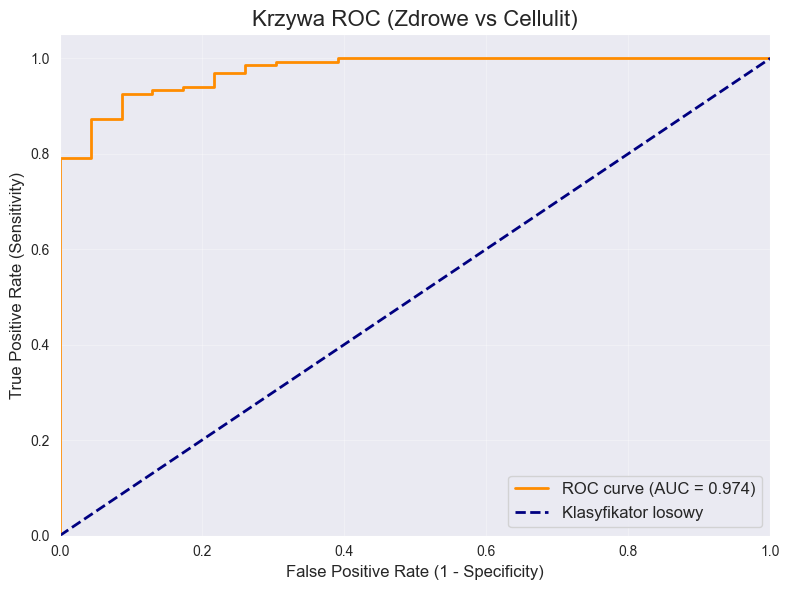

In [2]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
from PIL import Image
from collections import Counter
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from itertools import cycle

from scipy.special import softmax
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    f1_score, precision_score, recall_score,
    roc_curve, auc, cohen_kappa_score, matthews_corrcoef
)

class ThermalHistogramAndGray(object):
    def __init__(self, clip_limit=10, grid_size=(15, 15)):
        self.clip_limit = clip_limit
        self.grid_size = grid_size

    def __call__(self, img):
        img_np = np.array(img)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.grid_size)
        enhanced_gray = clahe.apply(gray)
        enhanced_rgb = cv2.cvtColor(enhanced_gray, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(enhanced_rgb)

class CelluliteDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label = torch.tensor(int(self.labels[idx]), dtype=torch.long)

        if self.transform:
            image_pil = Image.fromarray(image)
            image = self.transform(image_pil)

        return image, label

folder = "cellulit_data_without_scale_normalized"
classes = []
img_paths = []

for name in os.listdir(folder):
    img_paths.append(f"{folder}/" + name)
    name_split = name.split('.')[0].split('_')
    original_class = int(name_split[2])

    # Binarizacja klas: 0 zostaje 0 (Zdrowe), 1, 2, 3 stają się 1 (Cellulit)
    binary_class = 0 if original_class == 0 else 1
    classes.append(binary_class)

img_paths = np.array(img_paths)
classes = np.array(classes)

print(f"Liczba próbek w klasach: {Counter(classes)}")

mean_imagenet = [0.485, 0.456, 0.406]
std_imagenet = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    ThermalHistogramAndGray(),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_imagenet, std=std_imagenet)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    ThermalHistogramAndGray(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_imagenet, std=std_imagenet)
])

def get_model(device):
    model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[2].in_features
    # Zmiana wyjścia na 2 klasy (0 - Zdrowe, 1 - Cellulit)
    model.classifier[2] = nn.Linear(in_features, 2)

    for param in model.classifier[2].parameters():
        param.requires_grad = True

    return model.to(device)

K_FOLDS = 5
EPOCHS = 200
PATIENCE = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_results = []
all_true_labels = []
all_pred_labels = []
all_outputs = []

print(f"\nRozpoczynamy {K_FOLDS}-krotną walidację krzyżową...")

for fold, (train_idx, val_idx) in enumerate(skf.split(img_paths, classes)):
    print(f"\n{'='*30}")
    print(f"FOLD {fold + 1}/{K_FOLDS}")
    print(f"{'='*30}")

    fold_train_paths, fold_train_labels = img_paths[train_idx], classes[train_idx]
    fold_val_paths, fold_val_labels = img_paths[val_idx], classes[val_idx]

    train_dataset = CelluliteDataset(fold_train_paths, fold_train_labels, transform=train_transform)
    val_dataset = CelluliteDataset(fold_val_paths, fold_val_labels, transform=val_transform)

    counts = Counter(fold_train_labels)
    total_samples = len(fold_train_labels)
    num_classes = len(counts)
    weights = [total_samples / (num_classes * counts[c]) for c in sorted(counts.keys())]
    class_weights = torch.FloatTensor(weights).to(device)

    sample_weights = [weights[int(label)] for label in fold_train_labels]

    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

    model = get_model(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.classifier[2].parameters(), lr=0.001)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    fold_best_model_path = f'best_model_binary_fold_{fold+1}.pth'

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), fold_best_model_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"Early Stopping w epoce {epoch+1}.")
                break

    model.load_state_dict(torch.load(fold_best_model_path))
    model.eval()
    fold_correct = 0
    fold_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            fold_total += labels.size(0)
            fold_correct += (predicted == labels).sum().item()

            all_true_labels.extend(labels.cpu().numpy())
            all_pred_labels.extend(predicted.cpu().numpy())
            all_outputs.extend(outputs.cpu().numpy())

    fold_acc = 100 * fold_correct / fold_total
    fold_results.append(fold_acc)
    print(f"Najlepsze Accuracy dla FOLD {fold + 1}: {fold_acc:.2f}%")

print(f"\n{'='*40}")
print("SZCZEGÓŁOWE WYNIKI ZBIORCZE")
print(f"{'='*40}")

class_names = ['Zdrowe (0)', 'Cellulit (1)']
labels_list = [0, 1]

y_true = np.array(all_true_labels)
y_pred = np.array(all_pred_labels)
y_score = np.array(all_outputs)

y_prob = softmax(y_score, axis=1)
# Bierzemy prawdopodobieństwo klasy pozytywnej (Cellulit) do ROC
y_prob_positive = y_prob[:, 1]

top1_acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
precision_per_cls = precision_score(y_true, y_pred, average=None, zero_division=0)
recall_per_cls = recall_score(y_true, y_pred, average=None, zero_division=0)

kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Accuracy: {top1_acc*100:.2f}%")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Cohen's Kappa:  {kappa:.4f}")
print(f"Matthews Corrcoef (MCC): {mcc:.4f}\n")

print("Precision per class:")
for name, prec in zip(class_names, precision_per_cls):
    print(f"   - {name}: {prec:.4f}")

print("\nRecall (Sensitivity) per class:")
for name, rec in zip(class_names, recall_per_cls):
    print(f"   - {name}: {rec:.4f}")

cm = confusion_matrix(y_true, y_pred, labels=labels_list)
specificity_per_cls = []
for i in range(len(class_names)):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - tp - fn - fp
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity_per_cls.append(spec)

print("\nSpecificity per class:")
for name, spec in zip(class_names, specificity_per_cls):
    print(f"   - {name}: {spec:.4f}")

print("\n" + "-"*40)
print("RAPORT KLASYFIKACJI:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# --- RYSOWANIE MACIERZY BŁĘDÓW ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Zbiorcza Macierz Błędów (Cross-Validation)', fontsize=14)
plt.xlabel('Przewidziane przez model', fontsize=12)
plt.ylabel('Rzeczywiste (Ground Truth)', fontsize=12)
plt.tight_layout()
plt.show()

# --- RYSOWANIE KRZYWEJ ROC (Binarna) ---
fpr, tpr, _ = roc_curve(y_true, y_prob_positive)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Klasyfikator losowy')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Krzywa ROC (Zdrowe vs Cellulit)', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

✅ Zdjęcie zostało zapisane jako: transformed_output.jpg


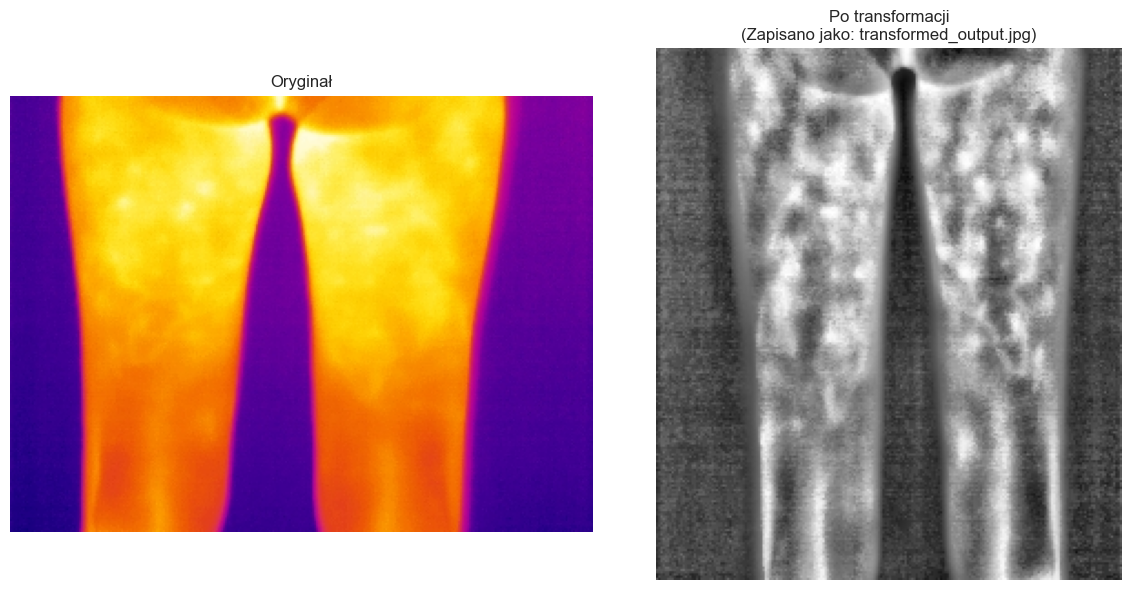

In [7]:
def show_transformation(img_path, save_name="transformed_output.jpg"):
    # 1. Wczytanie oryginału
    original_cv2 = cv2.imread(img_path)
    original_rgb = cv2.cvtColor(original_cv2, cv2.COLOR_BGR2RGB)
    original_pil = Image.fromarray(original_rgb)

    # 2. Zastosowanie transformacji (wynik to Tensor)
    transformed_tensor = train_transform(original_pil)

    # 3. Przygotowanie do wyświetlenia i zapisu (Denormalizacja)
    view_tensor = transformed_tensor.clone()
    view_tensor = denormalize(view_tensor, mean_imagenet, std_imagenet)

    # Zamiana na format NumPy (H, W, C) w zakresie 0-1
    transformed_np = view_tensor.permute(1, 2, 0).numpy()
    transformed_np = np.clip(transformed_np, 0, 1)

    # 4. ZAPISYWANIE ZDJĘCIA
    # Konwersja z 0-1 float na 0-255 uint8 (wymagane do zapisu obrazu)
    img_to_save = (transformed_np * 255).astype(np.uint8)

    # Konwersja RGB na BGR dla OpenCV i zapis
    img_to_save_bgr = cv2.cvtColor(img_to_save, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_name, img_to_save_bgr)
    print(f"✅ Zdjęcie zostało zapisane jako: {save_name}")

    # 5. Wyświetlanie porównania w oknie
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Oryginał")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(transformed_np)
    plt.title(f"Po transformacji\n(Zapisano jako: {save_name})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()







import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# Twoja klasa transformacji
class ThermalHistogramAndGray(object):
    def __init__(self, clip_limit=10, grid_size=(15, 15)):
        self.clip_limit = clip_limit
        self.grid_size = grid_size

    def __call__(self, img):
        img_np = np.array(img)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.grid_size)
        enhanced_gray = clahe.apply(gray)
        enhanced_rgb = cv2.cvtColor(enhanced_gray, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(enhanced_rgb)

# Parametry ImageNet
mean_imagenet = [0.485, 0.456, 0.406]
std_imagenet = [0.229, 0.224, 0.225]

# Definicja transformacji treningowej (z Twojego kodu)
train_transform = transforms.Compose([
    transforms.Resize((240, 210)),
    ThermalHistogramAndGray(),
    transforms.RandomHorizontalFlip(p=1.0), # p=1.0 tylko do testu, żeby zawsze odbijało
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_imagenet, std=std_imagenet)
])

def denormalize(tensor, mean, std):
    """Odwraca normalizację dla potrzeb wizualizacji."""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor


# --- UŻYCIE ---
# Podaj ścieżkę do dowolnego zdjęcia ze swojego folderu
folder = "cellulit_data_without_scale_normalized"
try:
    first_image = os.listdir(folder)[15]
    full_path = os.path.join(folder, first_image)
    show_transformation(full_path)
except Exception as e:
    print(f"Błąd: {e}. Upewnij się, że folder '{folder}' istnieje i zawiera zdjęcia.")